# Gemma 4 (E2B-it) - Continued Pretraining con Unsloth

Notebook de **continued pretraining** sobre `unsloth/gemma-4-E2B-it` (variante instruct) con Unsloth, usando un corpus de **manuales de taller de motocicletas** (Honda, Yamaha, Suzuki, KTM, AKT).

Pensado para Google Colab T4/L4 o GPU local con >=12 GB de VRAM.

**IMPORTANTE - se uso el modelo `-it` (instruct), no el base.** Esto preserva el chat template y el formato conversacional, pero requiere precauciones para no degradar el alineamiento que Google ya construyo:
- LoRA con `r` pequeno (32) en vez de 128
- **NO** entrenamos `embed_tokens`/`lm_head` (esto desalinearia los tokens especiales `<|turn>...`)
- `learning_rate` mucho mas bajo (1e-5)
- Formato del corpus respeta el `<eos>` para no contaminar otros documentos

Si lo que quieres es pretraining "puro" sobre dominio nuevo y no te importa perder el chat, cambia a `unsloth/gemma-4-E2B` y sube `r`/LR. Si lo que quieres es ensenar nuevas conversaciones, mejor usa el notebook de post-training.

**Que hace este notebook:**
1. Carga `unsloth/gemma-4-E2B-it` en 4-bit.
2. Adjunta adaptadores LoRA conservadores (sin tocar embeddings).
3. Entrena sobre `data/processed/pretraining.jsonl` (22 manuales de taller, ~2.16 M tokens).
4. Guarda el adapter para usarlo como punto de partida del SFT subsiguiente.

## 0. Setup HF (Xet desactivado + auth + cache)

**Ejecuta esta celda PRIMERO** tras reiniciar el kernel, antes de cualquier otra.

Fija las variables de entorno antes de que `huggingface_hub` se importe, para evitar que el cliente **Xet** se active. Xet provoca cuelgues silenciosos en descargas/uploads largos (la conexión TCP queda en `CLOSE-WAIT` y el cliente no se recupera). Con Xet desactivado, los uploads van por HTTP plano: más lentos pero estables.

Al ejecutarla deberías ver `OK: Xet desactivado` y `OK: auth como RobertGomezDP`. Si no, no continues.

In [ ]:
# ============================================================
# §0 Setup HF: env vars ANTES de cualquier import de huggingface_hub
# ============================================================
import os, pathlib

# 1) Desactivar Xet (cliente nuevo de HF que se cuelga en transfers grandes)
os.environ["HF_HUB_DISABLE_XET"] = "1"

# 2) Cache compartida (en SSD grande)
os.environ["HF_HOME"] = "/mnt/ssd2tb/hf_cache"
os.environ.setdefault("PYTORCH_ALLOC_CONF", "expandable_segments:True")

# 3) Token desde el sitio default del usuario (no se hardcodea en el notebook)
_TOKEN_PATH = pathlib.Path.home() / ".cache" / "huggingface" / "token"
if _TOKEN_PATH.exists():
    os.environ["HF_TOKEN"] = _TOKEN_PATH.read_text().strip()
else:
    print("AVISO: no se encontro token en ~/.cache/huggingface/token")
    print("  Ejecuta `hf auth login` en una terminal antes de subir nada a HF.")

# === Verificaciones ===
print("\n--- env vars ---")
print(f"HF_HUB_DISABLE_XET = {os.environ['HF_HUB_DISABLE_XET']}")
print(f"HF_HOME            = {os.environ['HF_HOME']}")
print(f"HF_TOKEN set       = {'HF_TOKEN' in os.environ}")

# Importa huggingface_hub DESPUES de fijar las env vars
from huggingface_hub.constants import HF_HUB_DISABLE_XET
from huggingface_hub import whoami

print("\n--- comprobacion ---")
if HF_HUB_DISABLE_XET:
    print("OK: Xet desactivado")
else:
    print("ERROR: Xet sigue ACTIVO (el modulo ya estaba importado). Reinicia el kernel.")

try:
    me = whoami(token=os.environ.get("HF_TOKEN"))
    print(f"OK: auth como {me['name']}")
except Exception as e:
    print(f"ERROR de auth: {e}")


--- env vars ---
HF_HUB_DISABLE_XET = 1
HF_HOME            = /mnt/ssd2tb/hf_cache
HF_TOKEN set       = True


/home/robert/Documents/Trabajo/Personal/hackaton/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



--- comprobacion ---
OK: Xet desactivado
OK: auth como RobertGomezDP


## 1. Instalación

In [ ]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    import torch; v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
    xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, '0.0.34')
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth
    !pip install --no-deps --upgrade "torchao>=0.16.0"
!pip install --no-deps transformers==5.5.0 "tokenizers>=0.22.0,<=0.23.0"
import torch; torch._dynamo.config.recompile_limit = 64;

## Atajo — solo cargar el modelo ya entrenado

Si solo quieres **probar** el adapter LoRA que ya entrenaste (sin reentrenar nada), ejecuta:

1. La celda de arriba (§1 Instalacion).
2. La celda de abajo (pre-descarga del base + carga del adapter).
3. La celda de §6 (Inferencia) para probarlo.

Saltas §2-§5 y §7 enteras.

In [ ]:
# ============================================================
# Atajo: cargar el adapter LoRA ya entrenado
# ============================================================
import os
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"           # descarga paralela + reanudable
os.environ["HF_HOME"]                  = "/mnt/ssd2tb/hf_cache"
os.environ.setdefault("PYTORCH_ALLOC_CONF", "expandable_segments:True")

# Pre-descarga del base 4-bit (~3 GB la primera vez; despues sale instantaneo de cache).
# Si se queda colgada, corta con Kernel->Interrupt y borra
# /mnt/ssd2tb/hf_cache/hub/.locks/models--unsloth--gemma-4-e2b-unsloth-bnb-4bit/
from huggingface_hub import snapshot_download
snapshot_download("unsloth/gemma-4-e2b-unsloth-bnb-4bit")

# Carga el LoRA encima del base.
from unsloth import FastModel

ADAPTER = "gemma4_e2b_motos_pretrained_lora"                       # local
# ADAPTER = "RobertGomezDP/piston-monkey-e2b-pretrained-lora"     # o desde HF

max_seq_length = 1024
model, tokenizer = FastModel.from_pretrained(
    model_name      = ADAPTER,
    max_seq_length  = max_seq_length,
    load_in_4bit    = True,
    full_finetuning = False,
)

print(f"\nModelo cargado desde: {ADAPTER}")
print("Salta a la celda de §6 (Inferencia) para probarlo.")

Fetching 10 files: 100%|██████████| 10/10 [00:00<00:00, 245.99it/s]


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.5.2: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA GeForce RTX 3060. Num GPUs = 1. Max memory: 11.622 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.6. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights: 100%|██████████| 2011/2011 [00:15<00:00, 128.68it/s]



Modelo cargado desde: gemma4_e2b_motos_pretrained_lora
Salta a la celda de §6 (Inferencia) para probarlo.


## 2. Cargar el modelo instruct

In [ ]:
import os
os.environ.setdefault("PYTORCH_ALLOC_CONF", "expandable_segments:True")

from unsloth import FastModel
import torch

max_seq_length = 1024

model, tokenizer = FastModel.from_pretrained(
    model_name      = "unsloth/gemma-4-E2B-it",
    max_seq_length  = max_seq_length,
    load_in_4bit    = True,
    full_finetuning = False,
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


/home/robert/Documents/Trabajo/Personal/hackaton/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.5.2: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA GeForce RTX 3060. Num GPUs = 1. Max memory: 11.622 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.6. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights: 100%|██████████| 2011/2011 [00:15<00:00, 130.81it/s]


## 3. Adaptadores LoRA conservadores

Sobre un modelo `-it` queremos **preservar el alineamiento**:
- `r=32` (capacidad moderada, evita sobreescribir mucho)
- **Sin `embed_tokens`/`lm_head`**: los tokens especiales del chat (`<|turn>`, `<turn|>`, `<bos>`, etc.) ya estan bien tokenizados y entrenarlos los desplaza.
- `use_rslora=False` (con r pequeno no aporta).

In [ ]:
model = FastModel.get_peft_model(
    model,
    r              = 32,
    target_modules = [
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
        # OJO: NO incluimos "embed_tokens" ni "lm_head" para no romper el chat template del -it
    ],
    lora_alpha     = 32,
    lora_dropout   = 0,
    bias           = "none",
    use_gradient_checkpointing = "unsloth",
    random_state   = 3407,
    use_rslora     = False,
    loftq_config   = None,
)

[unsloth_zoo.log|WARNING]Unsloth: Failed to register input-embedding hook for `model.base_model.model.model.audio_tower`: `get_input_embeddings` not auto‑handled for Gemma4AudioModel; please override in the subclass.. Falling back to pre-forward hook.


## 4. Dataset de pretraining

Cargamos el corpus local de manuales de taller de motocicletas desde `data/processed/pretraining.jsonl` (generado por `prepare_data.py`). Cada registro tiene los campos `title`, `text`, `brand`, `model`, `year`, `lang`.

Si ejecutas el notebook en Colab, sube el archivo o monta Drive y ajusta `DATA_PATH`.

In [ ]:
from datasets import load_dataset

# === Parametros del corpus ===
DATA_PATH = "data/processed/pretraining.jsonl"  # generado por prepare_data.py
SEED      = 3407

dataset = load_dataset("json", data_files=DATA_PATH, split="train")
dataset = dataset.shuffle(seed=SEED)

print("Manuales cargados:", len(dataset))
print("Marcas:", sorted(set(dataset["brand"])))
print("Titulo[0]:", dataset[0]["title"])
print("Chars totales:", sum(dataset["n_chars"]))
print("Texto[0] (300 chars):")
print(dataset[0]["text"][:300])

Manuales cargados: 22
Marcas: ['akt', 'honda', 'ktm', 'suzuki', 'yamaha']
Titulo[0]: Manual de Taller — YAMAHA XTZ 125E (2017)
Chars totales: 8624260
Texto[0] (300 chars):
## 2017

MANUAL DE SERVICIO

# XTZ125E

##### 2MD-F8197-S0

###### IMPORTANTE

Este manual ha sido editado por Yamaha Motor Company, Ltd. principalmente para uso de los concesionarios Yamaha y sus mecánicos cualificados. Resulta imposible incluir en un manual todos los conocimientos de un mecánico. 


### 4.1 (Opcional) Submuestreo balanceado por marca

El corpus tiene marcas con distinto numero de manuales (`honda=7`, `akt=5`, `suzuki=4`, `yamaha=3`, `ktm=3`). Si quieres una corrida mas rapida o un dataset equilibrado entre marcas, activa el submuestreo aqui.

- `BALANCED_SAMPLING = False` -> usa el dataset completo (default).
- `MAX_PER_BRAND = N` -> toma como mucho N manuales por marca.
- `TARGET_TOTAL = N` -> equivalente a `MAX_PER_BRAND = ceil(N / num_marcas)`.
- Si pones los dos, **gana `MAX_PER_BRAND`**.

In [ ]:
# ============================================================
# Submuestreo balanceado por marca (opcional)
# ============================================================
BALANCED_SAMPLING = False  # False -> usa los 22 manuales completos (recomendado)
MAX_PER_BRAND     = 4    # ej: 3 -> max 3 manuales por marca
TARGET_TOTAL      = 15    # ej: 15 -> ~3 por marca (5 marcas)

from collections import Counter
import math, random as _random

def balanced_subset(ds, max_per_brand=None, target_total=None, seed=3407):
    by_brand = {}
    for i, b in enumerate(ds["brand"]):
        by_brand.setdefault(b, []).append(i)
    n_brands = len(by_brand)
    if max_per_brand is None and target_total is not None:
        max_per_brand = max(1, math.ceil(target_total / n_brands))
    if max_per_brand is None:
        return ds
    rng = _random.Random(seed)
    chosen = []
    for b, idxs in by_brand.items():
        rng.shuffle(idxs)
        chosen.extend(idxs[:max_per_brand])
    rng.shuffle(chosen)
    return ds.select(chosen)

if BALANCED_SAMPLING:
    before = Counter(dataset["brand"])
    dataset = balanced_subset(dataset, MAX_PER_BRAND, TARGET_TOTAL, SEED)
    after = Counter(dataset["brand"])
    print(f"[balanced] {sum(before.values())} -> {sum(after.values())} manuales")
    print(f"  antes:   {dict(before)}")
    print(f"  despues: {dict(after)}")
else:
    print(f"[full] usando dataset completo: {len(dataset)} manuales")
    print(f"  por marca: {dict(Counter(dataset['brand']))}")

### 4.2 Formato del texto

Para pretraining concatenamos `título + \n\n + texto + EOS`. El `EOS` final separa documentos para que el modelo aprenda a cerrarlos y no contamine uno con otro.

Los manuales son largos (decenas de miles de caracteres), por lo que `UnslothTrainer` los troceará automáticamente en bloques de `max_length` tokens durante el entrenamiento.

In [ ]:
EOS = tokenizer.eos_token

def format_example(ex):
    return {"text": f"# {ex['title']}\n\n{ex['text']}{EOS}"}

dataset = dataset.map(
    format_example,
    remove_columns=[c for c in dataset.column_names if c != "text"],
)
dataset = dataset.shuffle(seed=3407)
print(dataset[0]["text"][:300])

Map: 100%|██████████| 18/18 [00:00<00:00, 272.99 examples/s]

# Manual de Taller — AKT AK (2020)

Funciones de las Bujías ......................................................2 Armortiguación (Consejos)................................................4 Cambiar el líquido de frenos..............................................6 Clasificación de los Aceites para


## 5. Entrenamiento con UnslothTrainer

Como **NO** entrenamos `embed_tokens`/`lm_head`, `embedding_learning_rate` queda sin efecto pero lo dejamos para que sea trivial reactivarlo si decides anadir esas capas.

LR base muy bajo (1e-5) para no degradar el alineamiento. Si tu corpus es muy distinto del de Google, puedes subir hasta 5e-5.

In [ ]:
from trl import SFTConfig
from unsloth import UnslothTrainer, UnslothTrainingArguments

trainer = UnslothTrainer(
    model            = model,
    processing_class = tokenizer,
    train_dataset    = dataset,
    args = UnslothTrainingArguments(
        dataset_text_field          = "text",
        max_length                  = max_seq_length,
        packing                     = True,        # empaqueta el corpus en bloques llenos (clave: sin esto se trunca cada manual a max_length)
        packing_strategy            = "wrapped",   # "wrapped" parte los manuales largos en trozos contiguos; "bfd" (default) los truncaria
        dataset_num_proc            = 2,

        per_device_train_batch_size = 1,
        gradient_accumulation_steps = 16,
        warmup_ratio                = 0.1,
        num_train_epochs            = 2,           # con packing cada epoca son ~130 steps reales (antes 15 epocas = 30 steps sobre datos truncados)
        # max_steps                 = 120,  # descomenta para una corrida corta de prueba

        learning_rate               = 1e-5,   # LR conservador para no danar el -it
        embedding_learning_rate     = 1e-6,   # sin efecto (no entrenamos embeddings), se deja por si los activas

        fp16 = not torch.cuda.is_bf16_supported(),
        bf16 = torch.cuda.is_bf16_supported(),

        logging_steps               = 1,
        optim                       = "adamw_8bit",
        weight_decay                = 0.01,
        lr_scheduler_type           = "cosine",
        seed                        = 3407,
        output_dir                  = "outputs_pretrain",
        report_to                   = "none",
    ),
)

In [ ]:
gpu = torch.cuda.get_device_properties(0)
start_mem = round(torch.cuda.max_memory_reserved()/1024**3, 3)
print(f"GPU = {gpu.name}. Max memory = {round(gpu.total_memory/1024**3,3)} GB. Reserved at start = {start_mem} GB.")

GPU = NVIDIA GeForce RTX 3060. Max memory = 11.622 GB. Reserved at start = 9.406 GB.


In [ ]:
trainer_stats = trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': 2}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 18 | Num Epochs = 15 | Total steps = 30
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 16
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 16 x 1) = 16
 "-____-"     Trainable parameters = 62,078,976 of 5,185,256,992 (1.20% trained)
Caching is incompatible with gradient checkpointing in Gemma4TextDecoderLayer. Setting `past_key_values=None`.


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss
1,0.399943
2,3.958610
3,0.405913
4,3.512312
5,0.404824
6,3.234921
7,0.399425
8,3.209611
9,0.392965
10,3.280757


Unsloth: Restored added_tokens_decoder metadata in outputs_pretrain/checkpoint-30/tokenizer_config.json.


In [ ]:
trainer_stats

TrainOutput(global_step=30, training_loss=1.8101925800244014, metrics={'train_runtime': 328.641, 'train_samples_per_second': 0.822, 'train_steps_per_second': 0.091, 'total_flos': 4037371474083840.0, 'train_loss': 1.8101925800244014, 'epoch': 15.0})

In [ ]:
used = round(torch.cuda.max_memory_reserved()/1024**3, 3)
print(f"Train runtime: {trainer_stats.metrics['train_runtime']:.1f}s ({trainer_stats.metrics['train_runtime']/60:.2f} min)")
print(f"Peak reserved memory: {used} GB ({round(used/(gpu.total_memory/1024**3)*100,2)} % de la GPU)")

Train runtime: 328.6s (5.48 min)
Peak reserved memory: 9.406 GB (80.93 % de la GPU)


### 5.1 Curva de training loss

Visualiza la evolucion del loss durante el entrenamiento. Funciona tanto si `trainer` sigue en memoria (post-`trainer.train()`) como si reiniciaste el kernel — en ese caso lee el ultimo checkpoint en `outputs_pretrain/`.

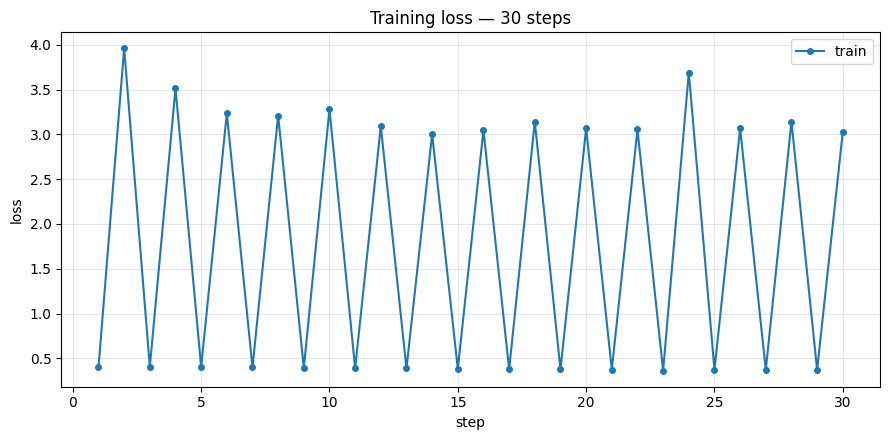

Fuente: trainer.state.log_history (memoria)
Loss inicial: 0.3999
Loss final:   3.0260
Reduccion:    -656.6%
Loss minimo:  0.3643 (step 23)


In [ ]:
# ============================================================
# Curva de training loss
# ============================================================
import matplotlib.pyplot as plt

# 1) Fuente de los logs: trainer en memoria o el ultimo checkpoint en disco
try:
    logs = trainer.state.log_history
    src  = "trainer.state.log_history (memoria)"
except NameError:
    import json, glob, os
    ckpts = sorted(glob.glob("outputs_pretrain/checkpoint-*"),
                   key=lambda p: int(p.rsplit("-", 1)[1]))
    if not ckpts:
        raise RuntimeError(
            "No hay `trainer` en memoria ni checkpoints en outputs_pretrain/. "
            "Ejecuta primero trainer.train()."
        )
    state = json.load(open(os.path.join(ckpts[-1], "trainer_state.json")))
    logs  = state["log_history"]
    src   = f"{ckpts[-1]}/trainer_state.json"

# 2) Separa train vs eval
train_pts = [(e["step"], e["loss"])      for e in logs if "loss"      in e and "eval_loss" not in e]
eval_pts  = [(e["step"], e["eval_loss"]) for e in logs if "eval_loss" in e]

if not train_pts:
    raise RuntimeError("No hay 'loss' en log_history. Asegurate de que logging_steps > 0.")

steps, losses = zip(*train_pts)

# 3) Plot
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(steps, losses, marker="o", markersize=4, linewidth=1.5, label="train")
if eval_pts:
    es, el = zip(*eval_pts)
    ax.plot(es, el, marker="s", markersize=4, linewidth=1.5, label="eval")
ax.set_xlabel("step")
ax.set_ylabel("loss")
ax.set_title(f"Training loss — {len(steps)} steps")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# 4) Resumen numerico
print(f"Fuente: {src}")
print(f"Loss inicial: {losses[0]:.4f}")
print(f"Loss final:   {losses[-1]:.4f}")
print(f"Reduccion:    {(losses[0] - losses[-1]) / losses[0] * 100:.1f}%")
print(f"Loss minimo:  {min(losses):.4f} (step {steps[losses.index(min(losses))]})")

## 6. Inferencia con chat template

Como mantenemos el formato conversacional del `-it`, usamos `apply_chat_template`.

In [ ]:
from transformers import TextStreamer

# Consulta del dominio para ver si el modelo absorbio el corpus de manuales
messages = [
    {"role": "user", "content": [
        {"type": "text", "text": "Describe el procedimiento general de mantenimiento de la cadena de transmision en una motocicleta."},
    ]},
]

inputs = tokenizer.apply_chat_template(
    messages,
    tokenize             = True,
    add_generation_prompt = True,
    return_tensors       = "pt",
).to("cuda")

streamer = TextStreamer(tokenizer, skip_prompt=True)
_ = model.generate(
    input_ids      = inputs,
    streamer       = streamer,
    max_new_tokens = 256,
    do_sample      = True,
    temperature    = 0.7,
    top_p          = 0.95,
    top_k          = 64,
    use_cache      = True,
)

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


## Procedimiento General de Mantenimiento de la Cadena de Transmisión en una Motocicleta

El mantenimiento adecuado de la cadena de transmisión es crucial para asegurar el correcto funcionamiento, la durabilidad y la eficiencia de la motocicleta. Una cadena bien mantenida previene fallos, reduce el desgaste y garantiza un rendimiento óptimo.

A continuación, se describe el procedimiento general de mantenimiento, que incluye inspección, limpieza, lubricación y, en casos necesarios, reemplazo.

---

### 1. Herramientas y Materiales Necesarios

Antes de comenzar, asegúrate de tener a mano lo siguiente:

* **Limpiador/Desengrasante:** Para eliminar suciedad, grasa y residuos.
* **Lubricante/Aceite para Cadena:** Específico para cadenas (generalmente grasa de litio o aceite ligero).
* **Trapos o Toallas:** Para limpiar y secar.
* **Herramientas (Opcional):** Llaves para ajustar la tensión (si es necesario), y herramientas para el desmontaje de componentes (si se requiere quitar la cadena).


## 7. Export del modelo

Bloque unificado para guardar el modelo localmente y/o subirlo a Hugging Face Hub. **Cada formato tiene dos toggles independientes** (local y HF), asi que puedes elegir cualquier combinacion.

**Tres formatos disponibles:**

| Formato | Tamano | Como se carga | Cuando usarlo |
|---|---|---|---|
| **LoRA adapter** | ~250 MB | `FastModel.from_pretrained("repo-lora")` → carga base + adapter | Iteracion rapida, comparte cambios sin re-subir el base |
| **16-bit fusionado** | ~5 GB | `AutoModelForCausalLM.from_pretrained("repo-16bit")` → modelo **completo standalone** | Servir en produccion (vLLM/TGI), no requiere el modelo base |
| **GGUF** | varia segun cuantizacion | llama.cpp / Ollama / LM Studio | Inferencia local CPU o cuantizada |

**Si quieres el modelo "ya cargable como uno solo, sin pegarle el adapter encima"** → activa `SAVE_LOCAL_16BIT` y/o `PUSH_16BIT_TO_HF`.

**Autenticacion HF:** ejecuta `huggingface-cli login` UNA vez, o exporta `HF_TOKEN=hf_...`. Evita hardcodear el token aqui si vas a commitear el notebook.

In [ ]:
# ============================================================
# Configuracion de export
# Cada formato tiene dos toggles independientes: LOCAL y HF.
# ============================================================

# --- 1. LoRA adapter (~250 MB) ---
#     Necesita el modelo base aparte (Unsloth/HF lo descargan solo).
SAVE_LOCAL_LORA = True
PUSH_LORA_TO_HF = True

# --- 2. Modelo fusionado 16-bit (~5 GB) ---
#     LoRA + base ya fusionados. Se carga STANDALONE con from_pretrained,
#     sin necesidad del modelo base. Listo para vLLM / TGI / transformers.
SAVE_LOCAL_16BIT = True
PUSH_16BIT_TO_HF = True

# --- 3. GGUF (cuantizado para llama.cpp / Ollama / LM Studio) ---
SAVE_LOCAL_GGUF = True
PUSH_GGUF_TO_HF = True

# === Destinos en Hugging Face ===
HF_REPO_LORA  = "RobertGomezDP/piston-monkey-e2b-pretrained-lora"
HF_REPO_16BIT = "RobertGomezDP/piston-monkey-e2b-pretrained-16bit"
HF_REPO_GGUF  = "RobertGomezDP/piston-monkey-e2b-pretrained-gguf"
HF_PRIVATE    = False
HF_TOKEN      = None    # se toma de ~/.cache/huggingface/token (celda §0) o de HF_TOKEN en el entorno; NUNCA hardcodear

# === Paths locales ===
LOCAL_LORA  = "gemma4_e2b_motos_pretrained_lora"
LOCAL_16BIT = "/mnt/ssd2tb/exports/gemma4-e2b-motos-pretrained-16bit"
LOCAL_GGUF  = "/mnt/ssd2tb/exports/gemma4-e2b-motos-pretrained-gguf"
GGUF_QUANTS = ["q4_k_m", "q8_0"]

import os
if SAVE_LOCAL_16BIT or SAVE_LOCAL_GGUF:
    os.makedirs("/mnt/ssd2tb/exports", exist_ok=True)

print("Plan de export:")
print(f"  LoRA   -> local={SAVE_LOCAL_LORA:5}  hf={PUSH_LORA_TO_HF:5}  ({HF_REPO_LORA if PUSH_LORA_TO_HF else '-'})")
print(f"  16-bit -> local={SAVE_LOCAL_16BIT:5}  hf={PUSH_16BIT_TO_HF:5}  ({HF_REPO_16BIT if PUSH_16BIT_TO_HF else '-'})")
print(f"  GGUF   -> local={SAVE_LOCAL_GGUF:5}  hf={PUSH_GGUF_TO_HF:5}  ({HF_REPO_GGUF if PUSH_GGUF_TO_HF else '-'})")

In [ ]:
# --- 1. LoRA adapter (ligero) ---
if SAVE_LOCAL_LORA:
    model.save_pretrained(LOCAL_LORA)
    tokenizer.save_pretrained(LOCAL_LORA)
    print(f"[local] LoRA guardada en: {LOCAL_LORA}")

if PUSH_LORA_TO_HF:
    model.push_to_hub(HF_REPO_LORA, token=HF_TOKEN, private=HF_PRIVATE)
    tokenizer.push_to_hub(HF_REPO_LORA, token=HF_TOKEN, private=HF_PRIVATE)
    print(f"[HF] LoRA: https://huggingface.co/{HF_REPO_LORA}")

if not (SAVE_LOCAL_LORA or PUSH_LORA_TO_HF):
    print("(LoRA: ambos toggles en False, nada que hacer)")

Unsloth: Restored added_tokens_decoder metadata in gemma4_e2b_motos_pretrained_lora/tokenizer_config.json.


[local] LoRA guardada en: gemma4_e2b_motos_pretrained_lora


adapter_model.safetensors: 100%|██████████| 248M/248M [00:44<00:00, 5.55MB/s] 


Saved model to https://huggingface.co/RobertGomezDP/piston-monkey-e2b-pretrained-lora


Unsloth: Restored added_tokens_decoder metadata in /tmp/tmp758hg8mm/tokenizer_config.json.
Upload 0 LFS files: 0it [00:00, ?it/s]
No files have been modified since last commit. Skipping to prevent empty commit.
[huggingface_hub.hf_api|WARNING]No files have been modified since last commit. Skipping to prevent empty commit.


[HF] LoRA: https://huggingface.co/RobertGomezDP/piston-monkey-e2b-pretrained-lora


In [ ]:
# --- 2. Modelo fusionado 16-bit (cargable standalone, sin adapter) ---
# Una vez subido, lo cargas como cualquier modelo HF:
#   from transformers import AutoModelForCausalLM, AutoTokenizer
#   model = AutoModelForCausalLM.from_pretrained(HF_REPO_16BIT)
#   tokenizer = AutoTokenizer.from_pretrained(HF_REPO_16BIT)
if SAVE_LOCAL_16BIT:
    model.save_pretrained_merged(LOCAL_16BIT, tokenizer, save_method="merged_16bit")
    print(f"[local] 16-bit guardado en: {LOCAL_16BIT}")

if PUSH_16BIT_TO_HF:
    model.push_to_hub_merged(HF_REPO_16BIT, tokenizer, save_method="merged_16bit",
                              token=HF_TOKEN, private=HF_PRIVATE)
    print(f"[HF] 16-bit: https://huggingface.co/{HF_REPO_16BIT}")

if not (SAVE_LOCAL_16BIT or PUSH_16BIT_TO_HF):
    print("(16-bit: ambos toggles en False, nada que hacer)")

Unsloth: Restored added_tokens_decoder metadata in /mnt/ssd2tb/exports/gemma4-e2b-motos-pretrained-16bit/tokenizer_config.json.


Found HuggingFace hub cache directory: /mnt/ssd2tb/hf_cache/hub
Checking cache directory for required files...


Unsloth: Copying 1 files from cache to `/mnt/ssd2tb/exports/gemma4-e2b-motos-pretrained-16bit`: 100%|██████████| 1/1 [00:45<00:00, 45.90s/it]


Successfully copied all 1 files from cache to `/mnt/ssd2tb/exports/gemma4-e2b-motos-pretrained-16bit`
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [02:06<00:00, 126.15s/it]


...

Found HuggingFace hub cache directory: /mnt/ssd2tb/hf_cache/hub
Checking cache directory for required files...


Unsloth: Copying 1 files from cache to `RobertGomezDP/piston-monkey-e2b-pretrained-16bit`: 100%|██████████| 1/1 [00:22<00:00, 22.30s/it]


Successfully copied all 1 files from cache to `RobertGomezDP/piston-monkey-e2b-pretrained-16bit`
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Preparing safetensor model files: 100%|██████████| 1/1 [00:00<00:00, 33825.03it/s]
model.safetensors: 100%|██████████| 10.2G/10.2G [27:16<00:00, 6.26MB/s]/s]
Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [29:05<00:00, 1745.91s/it]


Unsloth: Merge process complete. Saved to `/home/robert/Documents/Trabajo/Personal/hackaton/RobertGomezDP/piston-monkey-e2b-pretrained-16bit`
[HF] 16-bit: https://huggingface.co/RobertGomezDP/piston-monkey-e2b-pretrained-16bit


In [ ]:
# --- 3. GGUF para llama.cpp / Ollama / LM Studio ---
if SAVE_LOCAL_GGUF:
    model.save_pretrained_gguf(LOCAL_GGUF, tokenizer, quantization_method=GGUF_QUANTS)
    print(f"[local] GGUF guardado en: {LOCAL_GGUF}")

if PUSH_GGUF_TO_HF:
    model.push_to_hub_gguf(HF_REPO_GGUF, tokenizer, quantization_method=GGUF_QUANTS,
                            token=HF_TOKEN, private=HF_PRIVATE)
    print(f"[HF] GGUF: https://huggingface.co/{HF_REPO_GGUF}")

if not (SAVE_LOCAL_GGUF or PUSH_GGUF_TO_HF):
    print("(GGUF: ambos toggles en False, nada que hacer)")

Unsloth: Merging model weights to 16-bit format...


Unsloth: Restored added_tokens_decoder metadata in /mnt/ssd2tb/exports/gemma4-e2b-motos-pretrained-gguf/tokenizer_config.json.


Found HuggingFace hub cache directory: /mnt/ssd2tb/hf_cache/hub
Checking cache directory for required files...


Unsloth: Copying 1 files from cache to `/mnt/ssd2tb/exports/gemma4-e2b-motos-pretrained-gguf`: 100%|██████████| 1/1 [01:28<00:00, 88.71s/it]


Successfully copied all 1 files from cache to `/mnt/ssd2tb/exports/gemma4-e2b-motos-pretrained-gguf`
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [04:24<00:00, 264.70s/it]


Unsloth: Merge process complete. Saved to `/mnt/ssd2tb/exports/gemma4-e2b-motos-pretrained-gguf`
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF bf16 might take 3 minutes.
\        /    [2] Converting GGUF bf16 to ['q4_k_m', 'q8_0'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: llama.cpp found in the system. Skipping installation.
Unsloth: Preparing converter script...


[unsloth_zoo.llama_cpp|WARNING]Unsloth: No supported architectures (TEXT or VISION) could be determined from the original script.
[unsloth_zoo.llama_cpp|WARNING]Unsloth: Metadata branding patch target 'self.metadata = gguf.Metadata.load(...)' not found.
[unsloth_zoo.llama_cpp|WARNING]Unsloth: Qwen2MoE num_experts patch target not found.


Unsloth: [1] Converting model into bf16 GGUF format.
This might take 3 minutes...
Unsloth: Gemma4ForConditionalGeneration is not supported for MMPROJ conversion. Converting as text-only model.


## 8. Montar post-training

Abre `Gemma4_(E2B)_PostTraining.ipynb` y carga este adapter (`gemma4_e2b_motos_pretrained_lora`) como punto de partida del SFT con los pares conversacionales de `data/processed/posttraining.jsonl`.